# Librerias

In [3]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import r2_score

# Datos

In [4]:
df = pd.read_csv('datos.csv')

# Ingeniería de características

In [9]:
# Ordenar por lote y semana
df = df.sort_values(['Lote', 'Semana_prod'])

# Mortalidad acumulada por lote
df['Muertos_acum'] = df.groupby('Lote')['Muertos'].cumsum()

# Descartes acumulados
df['Descartes_acum'] = df.groupby('Lote')['Descartes'].cumsum()

# Aves vivas (asumiendo 4200 iniciales)
# Usaremos 4200 como constante para todos los lotes (ajusta si es diferente)
aves_iniciales = 4200
df['Aves_vivas'] = aves_iniciales - df['Muertos_acum'] - df['Descartes_acum']

# Peso anterior (lag 1)
df['Peso_anterior'] = df.groupby('Lote')['Peso_gr'].shift(1)

# Consumo iniciador anterior
df['Iniciador_anterior'] = df.groupby('Lote')['Iniciador_bolsas'].shift(1)

# Consumo terminador anterior
df['Terminador_anterior'] = df.groupby('Lote')['Terminador_bolsas'].shift(1)

# Días de producción: usamos una variable 'días' que acumule 7 por semana
df['Dias'] = df['Semana_prod'] * 7

# Eliminar filas sin peso anterior (primera semana de cada lote)
df_modelo = df.dropna(subset=['Peso_anterior']).copy()


# Modelo para predecir peso semanal

In [10]:
# Variables predictoras
features_peso = ['Semana_prod', 'Muertos_acum', 'Descartes_acum', 'Aves_vivas', 'Peso_anterior', 'Dias']
X_peso = df_modelo[features_peso]
y_peso = df_modelo['Peso_gr']

# Entrenamos Random Forest
rf_peso = RandomForestRegressor(n_estimators=100, random_state=42)
rf_peso.fit(X_peso, y_peso)

# Evaluación (error dentro de muestra)
pred_peso = rf_peso.predict(X_peso)
print("MAE peso:", mean_absolute_error(y_peso, pred_peso))
print("RMSE peso:", np.sqrt(mean_squared_error(y_peso, pred_peso)))


MAE peso: 62.34013888888889
RMSE peso: 87.58739233379048


* MAE (Error Absoluto Medio): 62.34 gramos: Significa que, en promedio, la predicción del peso semanal se desvía unos 62 gramos del peso real. Para pollos de engorde (pesos típicos entre 100 y 4500 g), este error es muy bajo (<2% en etapas finales).

* RMSE (Raíz del Error Cuadrático Medio): 87.59 gramos
Penaliza más los errores grandes. El valor indica que errores superiores a ~175 g son raros. El modelo es bastante preciso.

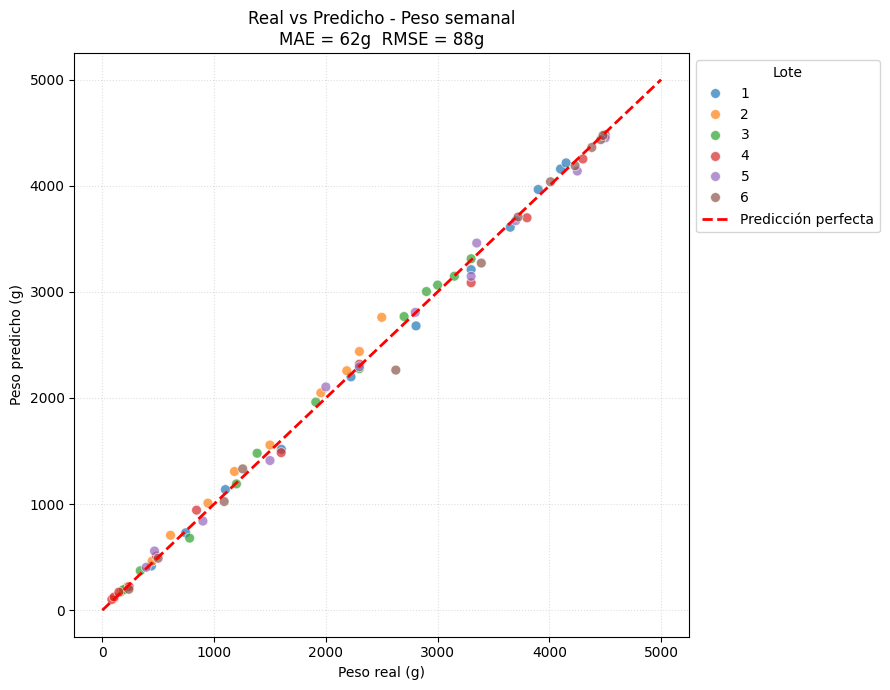

In [16]:
plt.figure(figsize=(9,7))
sns.scatterplot(data=df_modelo, x='Peso_gr', y='Peso_pred', hue='Lote', alpha=0.7, palette='tab10', s=50)
plt.plot([0, 5000], [0, 5000], 'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Peso real (g)')
plt.ylabel('Peso predicho (g)')
plt.title(f'Real vs Predicho - Peso semanal\nMAE = {62.3:.0f}g  RMSE = {87.6:.0f}g')
plt.legend(loc='upper left', bbox_to_anchor=(1,1), title='Lote')
plt.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.show()

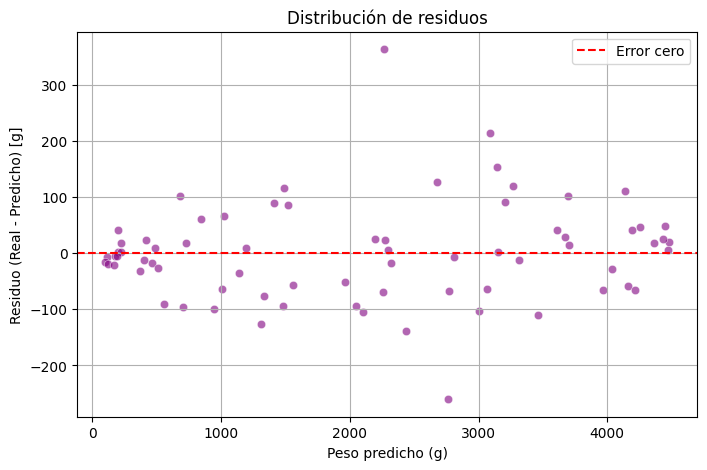

In [17]:
residuos = y_peso - pred_peso
plt.figure(figsize=(8,5))
sns.scatterplot(x=pred_peso, y=residuos, alpha=0.6, color='purple')
plt.axhline(y=0, color='r', linestyle='--', label='Error cero')
plt.xlabel('Peso predicho (g)')
plt.ylabel('Residuo (Real - Predicho) [g]')
plt.title('Distribución de residuos')
plt.legend()
plt.grid(True)
plt.show()

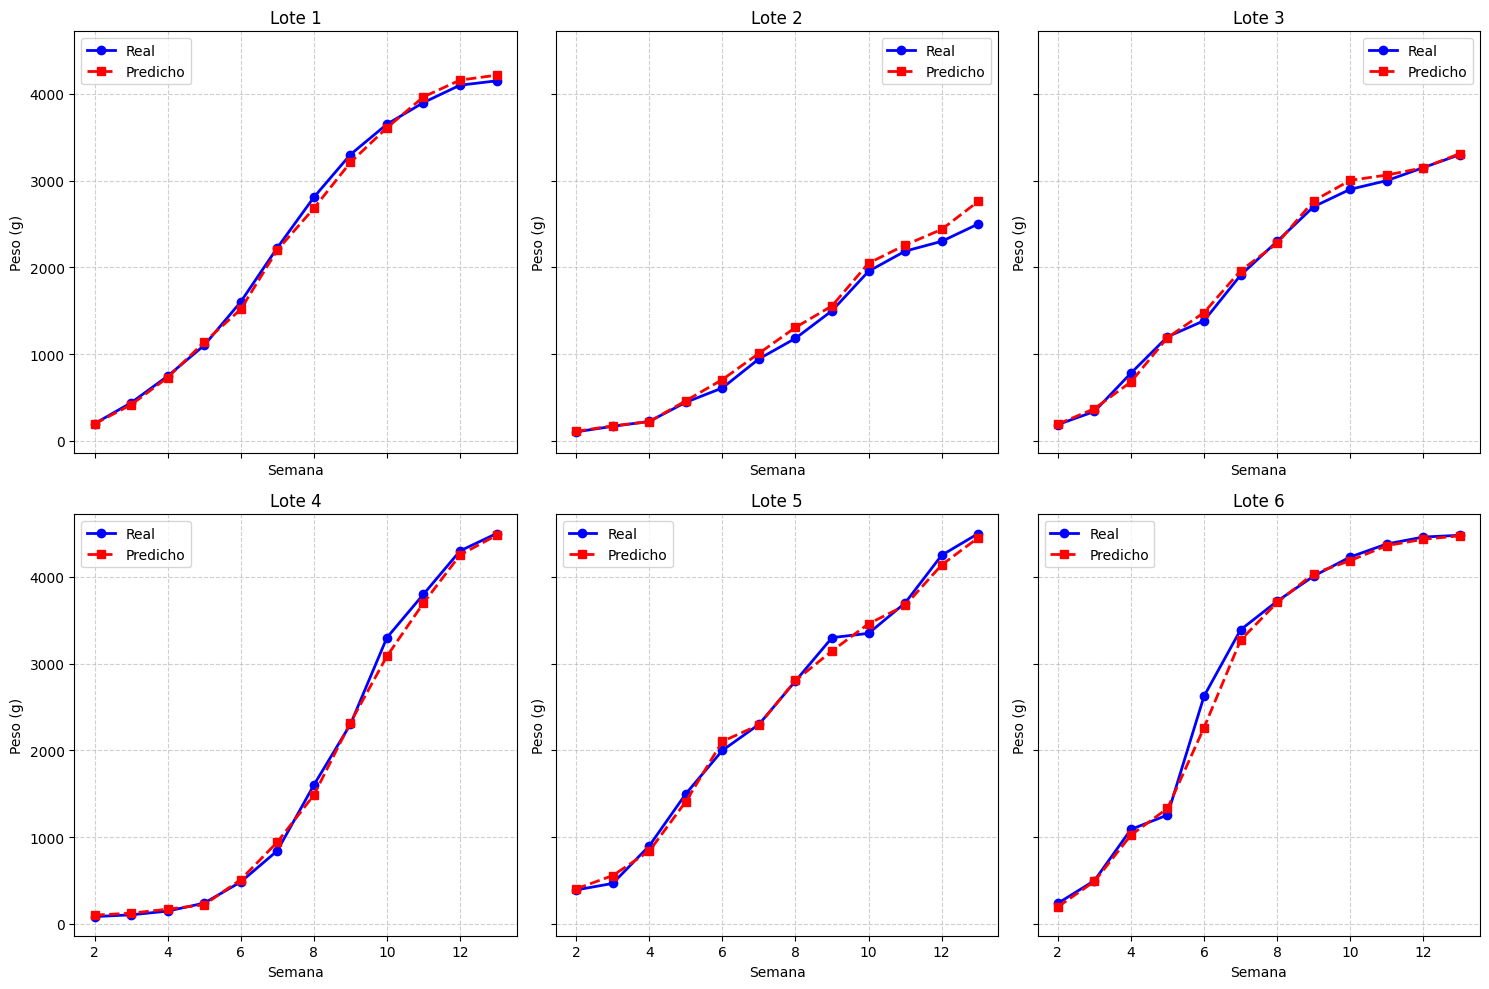

In [14]:

# Calculamos las predicciones si no lo has hecho
df_modelo['Peso_pred'] = pred_peso

# Definimos número de lotes
lotes = sorted(df_modelo['Lote'].unique())
n_lotes = len(lotes)
ncols = 3
nrows = (n_lotes + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, lote in enumerate(lotes):
    subset = df_modelo[df_modelo['Lote'] == lote]
    ax = axes[i]
    ax.plot(subset['Semana_prod'], subset['Peso_gr'], 'o-', color='blue', linewidth=2, label='Real')
    ax.plot(subset['Semana_prod'], subset['Peso_pred'], 's--', color='red', linewidth=2, label='Predicho')
    ax.set_title(f'Lote {lote}')
    ax.set_xlabel('Semana')
    ax.set_ylabel('Peso (g)')
    ax.legend()
    ax.grid(True, linestyle='--', alpha=0.6)

# Ocultar ejes vacíos si los hay
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


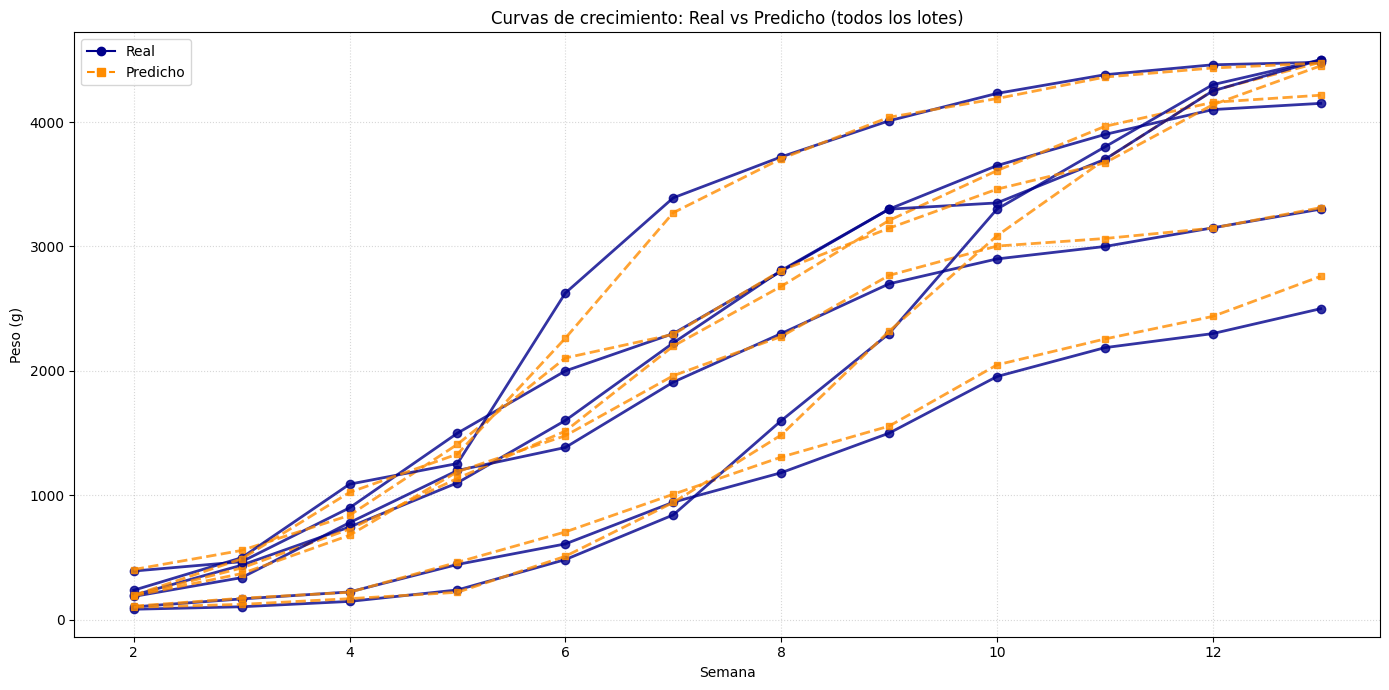

In [15]:
plt.figure(figsize=(14, 7))

# Colores fijos para real y predicho
color_real = 'darkblue'
color_pred = 'darkorange'

for lote in sorted(df_modelo['Lote'].unique()):
    subset = df_modelo[df_modelo['Lote'] == lote]
    # Real: línea sólida con marcador circular
    plt.plot(subset['Semana_prod'], subset['Peso_gr'], 'o-', color=color_real, linewidth=2, markersize=6, alpha=0.8)
    # Predicho: línea discontinua con marcador cuadrado
    plt.plot(subset['Semana_prod'], subset['Peso_pred'], 's--', color=color_pred, linewidth=2, markersize=5, alpha=0.8)

# Crear una sola leyenda manual (evitar duplicados)
real_line = plt.Line2D([0], [0], color=color_real, marker='o', linestyle='-', label='Real')
pred_line = plt.Line2D([0], [0], color=color_pred, marker='s', linestyle='--', label='Predicho')
plt.legend(handles=[real_line, pred_line], loc='upper left')

plt.xlabel('Semana')
plt.ylabel('Peso (g)')
plt.title('Curvas de crecimiento: Real vs Predicho (todos los lotes)')
plt.grid(True, linestyle=':', alpha=0.5)
plt.tight_layout()
plt.show()

# Modelo para consumo de iniciador y terminador


In [19]:
# Iniciador (solo semanas donde se usa, normalmente primeras)
df_iniciador = df_modelo[df_modelo['Iniciador_bolsas'] > 0].copy()
features_cons = ['Semana_prod', 'Peso_gr', 'Muertos_acum', 'Aves_vivas']
X_ini = df_iniciador[features_cons]
y_ini = df_iniciador['Iniciador_bolsas']
rf_ini = RandomForestRegressor()
rf_ini.fit(X_ini, y_ini)

# Terminador
df_terminador = df_modelo[df_modelo['Terminador_bolsas'] > 0].copy()
X_ter = df_terminador[features_cons]
y_ter = df_terminador['Terminador_bolsas']
rf_ter = RandomForestRegressor()
rf_ter.fit(X_ter, y_ter)

RandomForestRegressor()

# Modelo para un nuevo lote

In [20]:
def predecir_lote_nuevo(semanas=13, aves_iniciales=4200, muertos_estimados=None, descartes_estimados=None):
    """
    muertos_estimados: lista de muertos por semana (longitud semanas)
    descartes_estimados: lista de descartes por semana
    Si no se proporcionan, se usan los promedios históricos por semana.
    """
    if muertos_estimados is None:
        # Promedio de muertos por semana de lotes históricos
        muertos_estimados = df.groupby('Semana_prod')['Muertos'].mean().values[:semanas]
    if descartes_estimados is None:
        descartes_estimados = df.groupby('Semana_prod')['Descartes'].mean().values[:semanas]

    # Inicializar
    peso_actual = None
    muertos_acum = 0
    desc_acum = 0
    resultados = []

    for semana in range(1, semanas+1):
        aves_vivas = aves_iniciales - muertos_acum - desc_acum
        # Para semana 1, no hay peso anterior -> usar 118 (promedio primera semana)
        if semana == 1:
            peso_anterior = 118  # o mejor usar el promedio de semana 1 de los lotes
        else:
            peso_anterior = peso_actual

        X_pred = pd.DataFrame([[semana, muertos_acum, desc_acum, aves_vivas, peso_anterior, semana*7]],
                              columns=features_peso)
        peso_pred = rf_peso.predict(X_pred)[0]
        peso_actual = peso_pred

        # Predecir consumo iniciador y terminador de esta semana
        X_cons = pd.DataFrame([[semana, peso_pred, muertos_acum, aves_vivas]], columns=features_cons)
        ini_pred = rf_ini.predict(X_cons)[0] if semana <= 4 else 0  # normalmente iniciador hasta semana 4
        ter_pred = rf_ter.predict(X_cons)[0] if semana >= 4 else 0

        resultados.append({
            'Semana': semana,
            'Peso_gr': peso_pred,
            'Muertos_semana': muertos_estimados[semana-1],
            'Descartes_semana': descartes_estimados[semana-1],
            'Muertos_acum': muertos_acum,
            'Descartes_acum': desc_acum,
            'Aves_vivas': aves_vivas,
            'Iniciador_bolsas': max(0, ini_pred),
            'Terminador_bolsas': max(0, ter_pred)
        })

        # Actualizar acumulados (usando los estimados proporcionados)
        muertos_acum += muertos_estimados[semana-1]
        desc_acum += descartes_estimados[semana-1]

    return pd.DataFrame(resultados)


In [21]:
prediccion = predecir_lote_nuevo()
print(prediccion[['Semana', 'Peso_gr', 'Iniciador_bolsas', 'Terminador_bolsas']])

    Semana  Peso_gr  Iniciador_bolsas  Terminador_bolsas
0        1   191.54             44.53               0.00
1        2   370.31             63.08               0.00
2        3   570.36             82.41               0.00
3        4  1001.22             69.11             109.51
4        5  1344.65              0.00             169.97
5        6  2167.87              0.00             141.22
6        7  2464.39              0.00             189.72
7        8  2925.82              0.00             187.87
8        9  3146.52              0.00             136.82
9       10  3363.52              0.00             100.67
10      11  3740.91              0.00              62.94
11      12  4169.30              0.00              57.72
12      13  4406.70              0.00              27.27


# Resultados: Comparar peso real vs predicho (lotes 1–6)

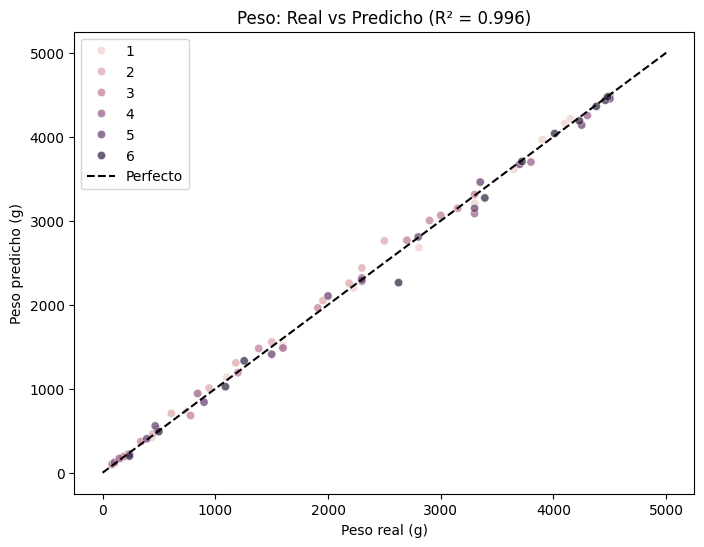

In [22]:
# Predecir sobre los mismos datos de entrenamiento (solo para ver ajuste)
df_modelo['Peso_pred'] = rf_peso.predict(df_modelo[features_peso])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_modelo, x='Peso_gr', y='Peso_pred', hue='Lote', alpha=0.7)
plt.plot([0, 5000], [0, 5000], 'k--', label='Perfecto')
plt.xlabel('Peso real (g)')
plt.ylabel('Peso predicho (g)')
plt.title(f'Peso: Real vs Predicho (R² = {r2_score(df_modelo["Peso_gr"], df_modelo["Peso_pred"]):.3f})')
plt.legend()
plt.show()

# Resultados: Evolución temporal del peso por lote (real vs predicho)

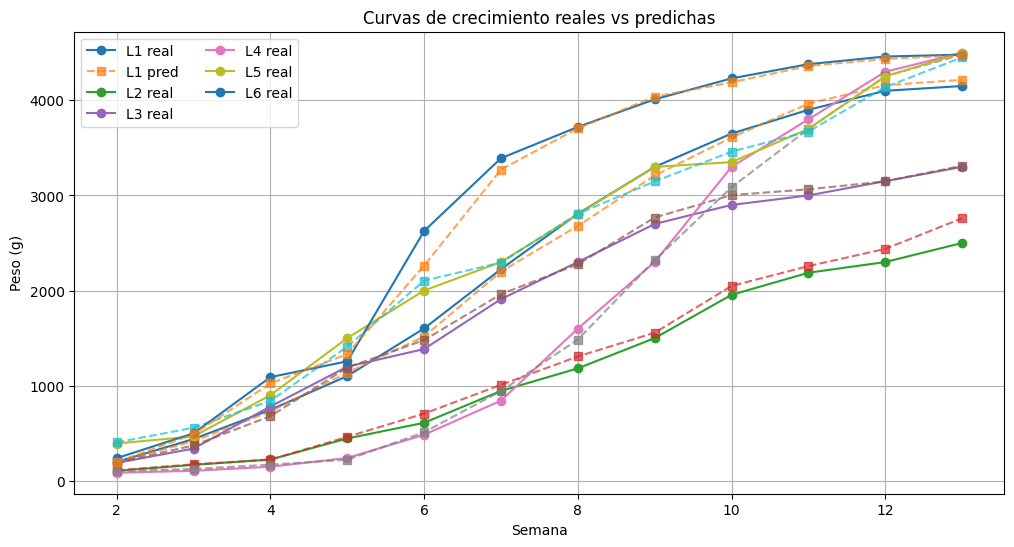

In [23]:
plt.figure(figsize=(12,6))
for lote in sorted(df_modelo['Lote'].unique()):
    subset = df_modelo[df_modelo['Lote'] == lote]
    plt.plot(subset['Semana_prod'], subset['Peso_gr'], 'o-', label=f'L{lote} real')
    plt.plot(subset['Semana_prod'], subset['Peso_pred'], 's--', label=f'L{lote} pred' if lote==1 else '', alpha=0.7)
plt.xlabel('Semana')
plt.ylabel('Peso (g)')
plt.title('Curvas de crecimiento reales vs predichas')
plt.legend(ncol=2)
plt.grid(True)
plt.show()

# Resultados: Consumo de iniciador y terminador (reales vs predichos)

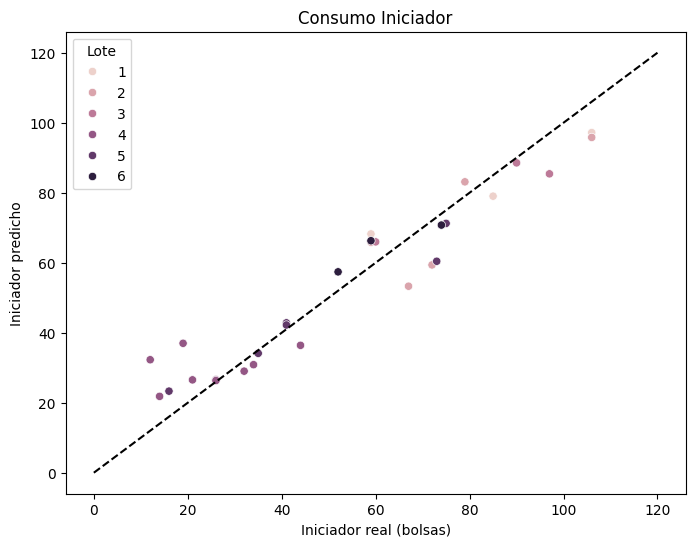

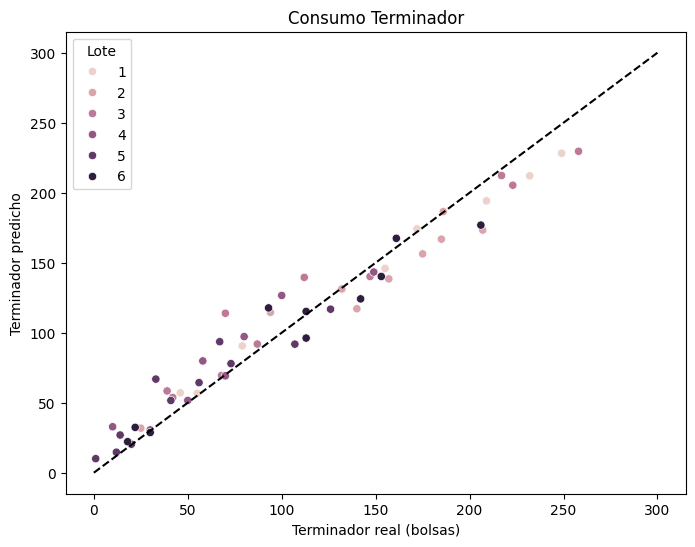

In [24]:
# Iniciador (solo semanas con >0)
df_iniciador = df_modelo[df_modelo['Iniciador_bolsas'] > 0].copy()
df_iniciador['Ini_pred'] = rf_ini.predict(df_iniciador[features_cons])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_iniciador, x='Iniciador_bolsas', y='Ini_pred', hue='Lote')
plt.plot([0, 120], [0, 120], 'k--')
plt.xlabel('Iniciador real (bolsas)')
plt.ylabel('Iniciador predicho')
plt.title('Consumo Iniciador')
plt.show()

# Terminador
df_terminador = df_modelo[df_modelo['Terminador_bolsas'] > 0].copy()
df_terminador['Ter_pred'] = rf_ter.predict(df_terminador[features_cons])

plt.figure(figsize=(8,6))
sns.scatterplot(data=df_terminador, x='Terminador_bolsas', y='Ter_pred', hue='Lote')
plt.plot([0, 300], [0, 300], 'k--')
plt.xlabel('Terminador real (bolsas)')
plt.ylabel('Terminador predicho')
plt.title('Consumo Terminador')
plt.show()

# Resultados: Predicción para lotes 7 y 8 (con datos reales disponibles parcialmente)

In [29]:
# Si tu archivo original ya tiene L7 y L8, extraemos los reales (con NaNs)
df_lotes_reales = df.copy()  # el original completo
df_l7_real = df_lotes_reales[df_lotes_reales['Lote'] == 7]
df_l8_real = df_lotes_reales[df_lotes_reales['Lote'] == 8]
df_l8_real.head(5)

,Lote,Semana_prod,Peso_gr,Muertos,Descartes,Iniciador_bolsas,Terminador_bolsas,Muertos_acum,Descartes_acum,Aves_vivas,Peso_anterior,Iniciador_anterior,Terminador_anterior,Dias
